# Activation Functions In Neural Networks 

## INTRODUCTION: 

* Activation functions play a crucial role in the functioning of neural networks. 
* They introduce **non-linearity** into the model, allowing it to learn and represent complex patterns in data. 
* Without activation functions neural networks would simply be linear models, limiting their ability to solve real-world problems effectively. 
* This guide provides an overview of the most commonly used activation functions and their mathematical definitions, advantages, disadvantages, and practical implementations in code to help you understand and apply them in your machine learning projects.

* Activation functions are the cornerstone of deep learning models. 
* They introduce non-linearity, enabling neural networks to learn complex patterns beyond simple linear relationships.
   
`In this blog, we’ll explore the types of activation functions, their mathematical formulations, advantages, disadvantages, practical use cases, and code implementations`

## 1.What is an  Activation Function? 

An activation function is a mathematical function applied to the output of a neuron that determines whether and how strongly the neuron is activated, by transforming its input into a suitable output signal


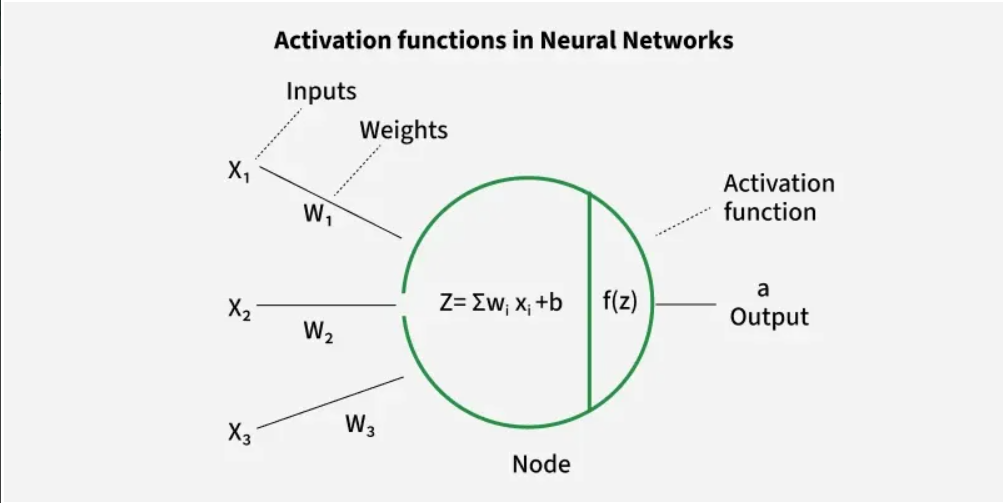

### Mathematical Example 
* Inputs: I1, I2
* Hidden layer: neurons H1 and H2
* Output layer: one neuron (output)
* Weights: w1, w2, w3, w4, w5, w6
* Biases: b1 for hidden layer, b2 for output layer

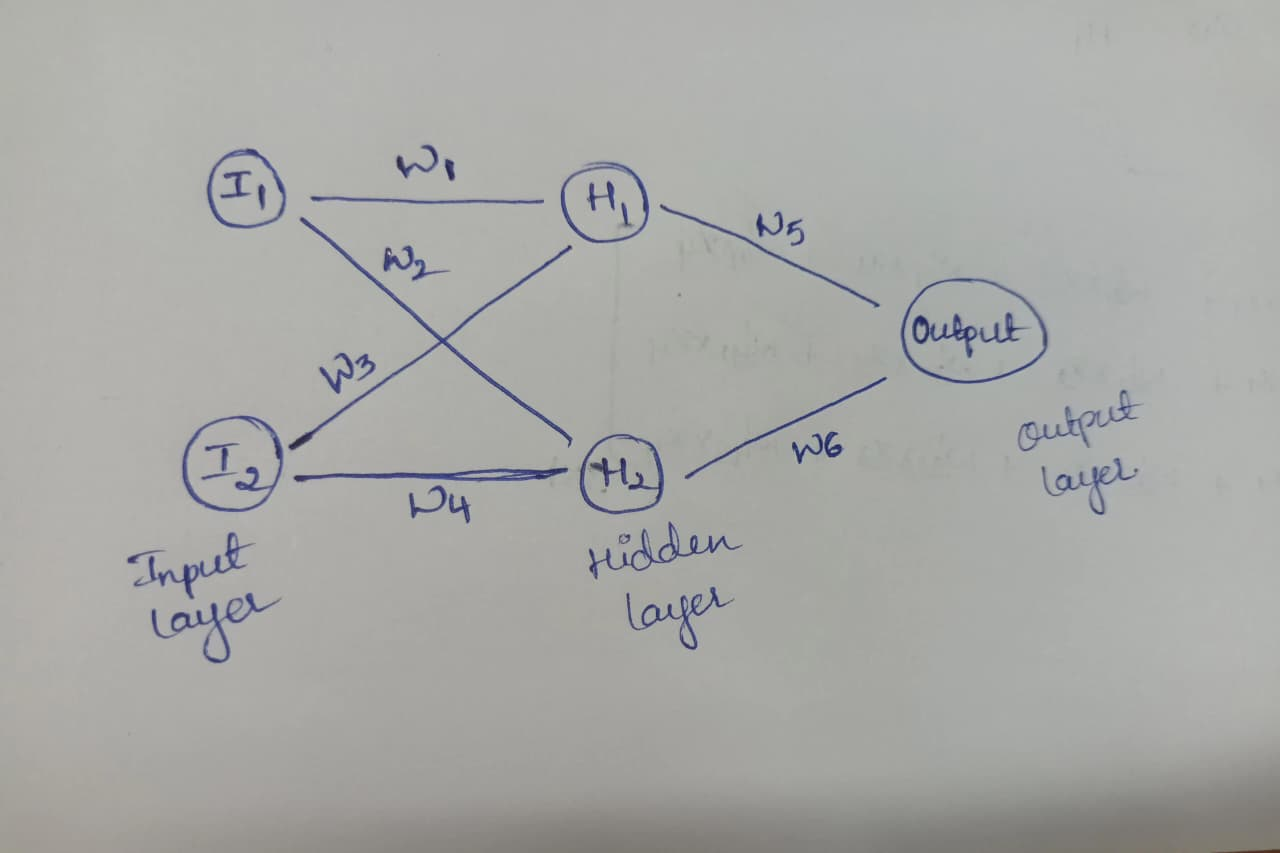

* The Hidden layer Outputs are: 

  `H1 = I1w1 +I2w3 +b`
  
  `H2 = I1w2 +I2w4 +b`

* The output before activation is:

  `Output = H1w5 + H2w6 + b`

* Without activation, these are linear equations.

* To introduce non-linearity, we apply a sigmoid activation:

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$
                
* `FinalOutput =  Sigmoid(Output)`


* This gives the final output of the network after applying the sigmoid activation function in output layers, introducing the desired non-linearity



## 2. Types of Activation Functions? 

1. Sigmoid Function
2. Hyperbolic Tangent (Tanh)
3. Leaky ReLU
4. Rectified Linear Unit (ReLU)
5. Exponential Linear Unit (ELU)
6. SELU
7. Gaussian Error Linear Unit (GELU)
8. Softmax Function
9. Softplus
10. Swish Function


#### `@ Linear Activation Function:`

* A linear activation function simply `returns the input as it is`
* **Formula** `F(X) = X`
* **Range**--- (-∞, ∞)
* **Use Cases**:It is used in Output layer for  (Regression problems)
   * Ex: house price prediction, salary prediction
* Not used in Hidden layers& Classification tasks
* **Advantages**:
   * Simple and fast
   * No gradient vanishing problem
   * Works well for continuous output prediction
   * Easy to interpret (direct relationship)
     
* **Disadvnatges**:
   * No non-linearity
   * Cannot learn complex patterns
   * Multiple layers become equivalent to single layer
     
    
* Linear activation function passes input directly as output and is mainly used in regression tasks where continuous values are predicted

In [2]:
# Basic python 
def linear_activation(x):
    return x
print(linear_activation(1))
print(linear_activation(-1))

# Using Numpy (for arrays/ML)
import numpy as np
x = np.array([1,2,3,4,5])
print(linear_activation(x))

# In Neural Networks(Manual Forward)

# inputs
x = np.array([2, 3])

# weights
w = np.array([0.5, 0.8])

# bias
b = 1

# linear combination
z = np.dot(w, x) + b

# activation (linear)
output = z

print("Output:", output)

# Using Tensorflow/ Keras 
import keras 
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential([
    Dense(1, activation='linear',input_shape=(2,))
])
model

1
-1
[1 2 3 4 5]
Output: 4.4


C:\Users\dadof\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


<Sequential name=sequential, built=True>

In [3]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

model = Sequential([
    Input(shape=(2,)),          
    Dense(1, activation='linear')
])
model

<Sequential name=sequential_1, built=True>

#### ` @ Non-Linear Activation Funtions`

1. sigmoid
2. tanh
3. Relu
4. LeakyRelu
5. softplus
6. swish


### 1.Sigmoid: 

* A sigmoid activation function `converts input into probability-like output`

* **Formula**:
$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

* **Range** — (0, 1)
* **Use Cases**: Used in Output layer (Binary Classification)
          * Ex: spam detection, yes/no prediction
* Not used in deep hidden layers (vanishing gradient problem)
* **Advantages:**
    * Output interpretable as probability
    * Smooth and differentiable
* **Disadvantages:**

   * Vanishing gradient problem
   * Not zero-centered
   * Slow training


In [4]:
# python 
import math

def sigmoid(x):
    return 1 / (1 + math.exp(-x))

print(sigmoid(1)) 

# Numpy 
import numpy as np

def sigmoid(x):
    return 1 / (1 + np.exp(-x))
x = np.array([-2, -1, 0, 1, 2])
print(sigmoid(x))

# Tensorflow/Keras 
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential([
    Dense(10, activation='sigmoid',input_shape=(5,))
])
model

     # or 

from tensorflow.keras.layers import Dense
model = Sequential([
    Input(shape=(5,)),
    Dense(10, activation='sigmoid')
])
model


0.7310585786300049
[0.11920292 0.26894142 0.5        0.73105858 0.88079708]


<Sequential name=sequential_3, built=True>

In [5]:
from tensorflow.keras.layers import Dense
model = Sequential([
    Input(shape=(5,)),
    Dense(10, activation='sigmoid')
])
model

<Sequential name=sequential_4, built=True>

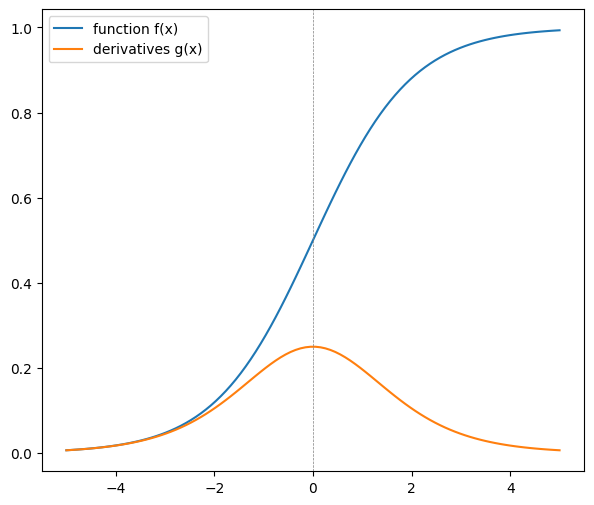

In [6]:
# Visualization
import matplotlib.pyplot as plt
# Numerical Differentiation
def num_differentiation(f, x, h):
    return (f(x+h) - f(x-h)) / (2. * h)

x = np.linspace(-5, 5, 100)

h = 1e-08
f = sigmoid
fx = f(x)
gx = num_differentiation(f, x, h)

# Visualization
plt.figure(figsize=(7,6))
plt.plot(x, fx, label='function f(x)')
plt.plot(x, gx, label='derivatives g(x)')
plt.axvline(x=0, ls='--', lw=0.5, c='gray')
plt.legend()
plt.show()

### 2.Tanh

* A tanh activation function maps input between -1 and 1

* **Formula:** tanh(x)
* **Range** — (-1, 1)
* **Use Cases:** Used in Hidden layers
  * Better alternative to sigmoid
* **Advantages:**

  * Zero-centered output
  * Stronger gradients than sigmoid
* **Disadvantages:**

  * Still suffers from vanishing gradient
  * Computationally heavier than ReLU

In [7]:
# Python
def tanh(x):
    return math.tanh(x)

print(tanh(5))

# Numpy 
def tanh(x):
    return np.tanh(x)

print("Tanh:", tanh(x))

# TensorFlow / Keras Implementation
model = Sequential([
    Dense(10, activation='tanh',input_shape=(5,))
])
model

0.9999092042625951
Tanh: [-0.9999092  -0.99988888 -0.999864   -0.99983356 -0.9997963  -0.99975071
 -0.9996949  -0.99962661 -0.99954304 -0.99944077 -0.99931562 -0.99916247
 -0.99897506 -0.99874575 -0.99846517 -0.99812189 -0.99770192 -0.99718816
 -0.99655975 -0.99579119 -0.99485138 -0.99370237 -0.99229794 -0.99058177
 -0.98848543 -0.98592577 -0.98280203 -0.97899231 -0.97434958 -0.96869703
 -0.96182292 -0.95347493 -0.94335424 -0.93110961 -0.91633212 -0.89855128
 -0.87723379 -0.85178653 -0.82156588 -0.78589571 -0.74409659 -0.69552835
 -0.63964681 -0.57607333 -0.5046724  -0.4256282  -0.33950714 -0.24729097
 -0.15036626 -0.05046215  0.05046215  0.15036626  0.24729097  0.33950714
  0.4256282   0.5046724   0.57607333  0.63964681  0.69552835  0.74409659
  0.78589571  0.82156588  0.85178653  0.87723379  0.89855128  0.91633212
  0.93110961  0.94335424  0.95347493  0.96182292  0.96869703  0.97434958
  0.97899231  0.98280203  0.98592577  0.98848543  0.99058177  0.99229794
  0.99370237  0.99485138  

<Sequential name=sequential_5, built=True>

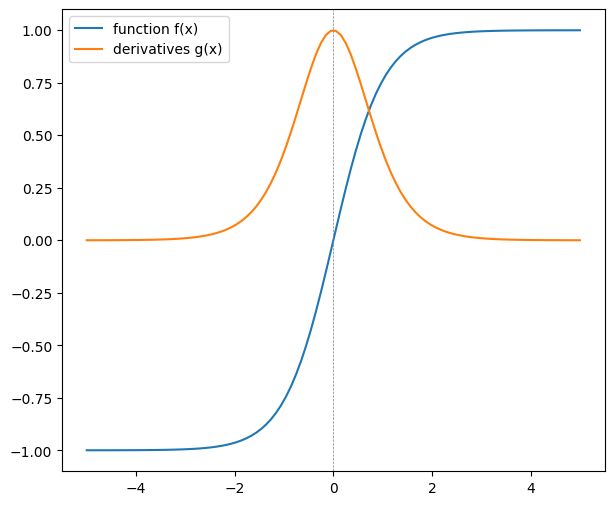

In [8]:
# activation function
def tanh(x): return np.tanh(x)

# Numerical Differentiation
def num_differentiation(f, x, h):
    return (f(x+h) - f(x-h)) / (2. * h)

x = np.linspace(-5, 5, 100)

h = 1e-08
f = tanh
fx = f(x)
gx = num_differentiation(f, x, h)

# Visualization
plt.figure(figsize=(7,6))
plt.plot(x, fx, label='function f(x)')
plt.plot(x, gx, label='derivatives g(x)')
plt.axvline(x=0, ls='--', lw=0.5, c='gray')
plt.legend()
plt.show()

### 3.ReLU (Rectified Linear Unit):
* ReLU outputs zero for negative values and input for positive values

* **Formula**: f(x)=max(0,x)
* **Range** — [0, ∞)
* **Use Cases**: Most commonly used in Hidden layers
* **Advantages**:

  * Fast and simple
  * Reduces vanishing gradient problem
  * Sparse activation (efficient)
    
* **Disadvantages:**
  * Dead neuron problem (output becomes 0 permanently)
  * Not zero-centered

In [9]:
def relu(x):
    return max(x)

print(relu(x))

# Numpy 
def relu(x):
    return np.maximum(0, x)

print(relu(x))

# TensorFlow / Keras Implementation
model = Sequential([
    Dense(10, activation='relu',input_shape=(5,))
])
model

5.0
[0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.05050505 0.15151515 0.25252525 0.35353535
 0.45454545 0.55555556 0.65656566 0.75757576 0.85858586 0.95959596
 1.06060606 1.16161616 1.26262626 1.36363636 1.46464646 1.56565657
 1.66666667 1.76767677 1.86868687 1.96969697 2.07070707 2.17171717
 2.27272727 2.37373737 2.47474747 2.57575758 2.67676768 2.77777778
 2.87878788 2.97979798 3.08080808 3.18181818 3.28282828 3.38383838
 3.48484848 3.58585859 3.68686869 3.78787879 3.88888889 3.98989899
 4.09090909 4.19191919 4.29292929 4.39393939 4.49494949

<Sequential name=sequential_6, built=True>

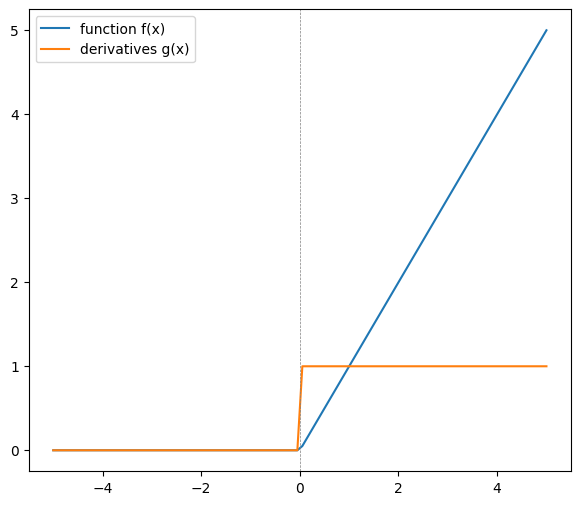

In [20]:
# activation function
def relu(x): return np.maximum(0, x)

# Numerical Differentiation
def num_differentiation(f, x, h):
    return (f(x+h) - f(x-h)) / (2. * h)

x = np.linspace(-5, 5, 100)

h = 1e-08
f = relu
fx = f(x)
gx = num_differentiation(f, x, h)

# Visualization
plt.figure(figsize=(7,6))
plt.plot(x, fx, label='function f(x)')
plt.plot(x, gx, label='derivatives g(x)')
plt.axvline(x=0, ls='--', lw=0.5, c='gray')
plt.legend()
plt.show()

### 4.Leaky ReLU:
* Leaky ReLU allows small negative values instead of zero

* **Formula:**

 $$
  f(z) =
  \begin{cases}
    z & \text{if } z \geq 0 \\
    \alpha z & \text{if } z < 0 \ \ (\alpha \ll 1)
  \end{cases}
  $$

* **Range** — (-∞, ∞)
* **Use Cases**: Used in Hidden layers (fix ReLU problem)
* **Advantages**:
   * Prevents dead neurons
   * Better gradient flow
* **Disadvantages**:
   * α (slope) must be chosen
   * Slightly more complex than ReLU

In [10]:
def leaky_relu(x, alpha=0.01):
    return x if x > 0 else alpha * x

print(leaky_relu(3))

def leaky_relu(x, alpha=0.01):
    return np.where(x > 0, x, alpha * x) 

print(leaky_relu(3))

model = Sequential([
    Dense(10, activation='leaky_relu',input_shape=(5,))
])
model

3
3.0


<Sequential name=sequential_7, built=True>

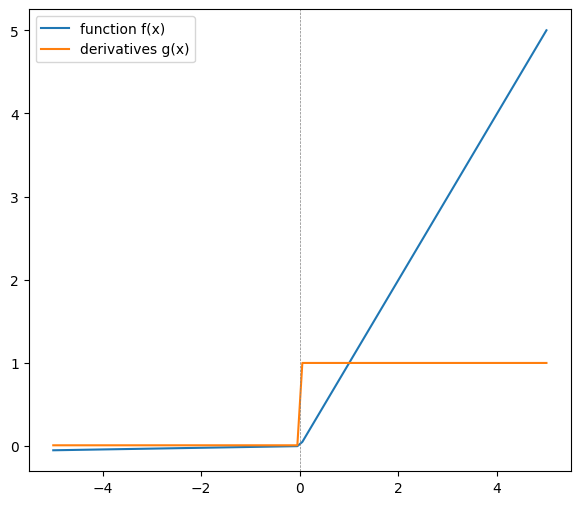

In [21]:
# activation function
def leaky_relu(x):
  alpha = 0.01
  return np.maximum(alpha*x, x)

# Numerical Differentiation
def num_differentiation(f, x, h):
    return (f(x+h) - f(x-h)) / (2. * h)

x = np.linspace(-5, 5, 100)

h = 1e-08
f = leaky_relu
fx = f(x)
gx = num_differentiation(f, x, h)

# Visualization
plt.figure(figsize=(7,6))
plt.plot(x, fx, label='function f(x)')
plt.plot(x, gx, label='derivatives g(x)')
plt.axvline(x=0, ls='--', lw=0.5, c='gray')
plt.legend()
plt.show()

### 5.Softplus:
* Softplus is a smooth version of ReLU

* **Formula**:

$$
f(x) = \ln(1 + e^x)
$$

* **Range** — (0, ∞)
* **Use Cases**: Used in Hidden layers (rare)
* **Advantages**:
   * Smooth and differentiable everywhere
   * No dead neuron problem
* **Disadvantages**:

   * Computationally expensive
   * Less commonly used than ReLU

In [11]:
# python
def softplus(x):
    return math.log(1 + math.exp(x))
    
print(softplus(5))
# Numpy 
def softplus(x):
    return np.log(1 + np.exp(x))

print(softplus(4))

# tensorflow/keras
model = Sequential([
    Dense(10, activation='softplus',input_shape=(5,))
])
model

5.006715348489118
4.0181499279178094


<Sequential name=sequential_8, built=True>

### 6.Swish:
* A swish activation function multiplies input with its sigmoid value

* **Formula**:

$$
f(x) = x \cdot \sigma(\beta x)
$$

* **Range** — (-∞, ∞)
* **Use Cases**: Used in Hidden layers (Modern Deep Learning models)
   * Ex: EfficientNet, deep CNNs
   * Not commonly used in Output layer
* **Advantages**:
    * Smooth and non-linear
    * Better gradient flow than ReLU
    * Allows small negative values
    * Improves performance in deep networks
* **Disadvantages**:
   * Computationally expensive than ReLU
   * Slower training in some cases
   * Not always significantly better than ReLU

In [12]:
# Python 
def swish(x):
    return x * (1 / (1 + math.exp(-x)))   # x * sigmoid(x)

print(swish(2))
print(swish(-2))

# Numpy 
def swish(x):
    return x * (1 / (1 + np.exp(-x)))

print(swish(2))
print(swish(-2))

# Keras
model = Sequential([
    Input(shape=(5,)),
    Dense(10, activation='swish'),   
    Dense(1)
])
model

1.7615941559557646
-0.2384058440442351
1.7615941559557646
-0.2384058440442351


<Sequential name=sequential_9, built=True>

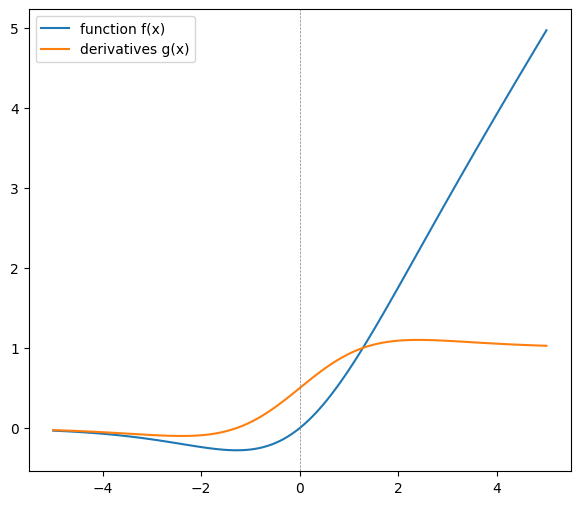

In [22]:
# activation function
def swish(x): return x*sigmoid(x)

# Numerical Differentiation
def num_differentiation(f, x, h):
    return (f(x+h) - f(x-h)) / (2. * h)

x = np.linspace(-5, 5, 100)

b = 1
h = 1e-08
f = swish
fx = f(x)
gx = num_differentiation(f, x, h)

# Visualization
plt.figure(figsize=(7,6))
plt.plot(x, fx, label='function f(x)')
plt.plot(x, gx, label='derivatives g(x)')
plt.axvline(x=0, ls='--', lw=0.5, c='gray')
plt.legend()
plt.show()

In [13]:
# Keras Implementation

# ----------------------------------------------------

# ------------ Using Built-in ----------------
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

model = Sequential([
    Input(shape=(5,)),
    Dense(10, activation='relu'),
    Dense(10, activation='tanh'),
    Dense(10, activation='sigmoid'),
    Dense(10, activation='softplus'),
    Dense(10, activation='linear'),
    Dense(1, activation= 'swish')
])
model

<Sequential name=sequential_10, built=True>

In [14]:
model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_11 (Dense)                     │ (None, 10)                  │              60 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_12 (Dense)                     │ (None, 10)                  │             110 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_13 (Dense)                     │ (None, 10)                  │             110 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_14 (Dense)                     │ (None, 10)                  │             110 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_15 (Dense)                     │ (None, 10)                  │             110 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_16 (Dense)                     │ (None, 1)                   │              11 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 511 (2.00 KB)

 Trainable params: 511 (2.00 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# TensorFlow 
import tensorflow as tf

x = tf.constant([-2.0, -1.0, 0.0, 1.0, 2.0])

print("Sigmoid:", tf.nn.sigmoid(x))
print("__"*30)
print("Tanh:", tf.nn.tanh(x))
print("__"*30)
print("ReLU:", tf.nn.relu(x))
print("__"*30)
print("Leaky ReLU:", tf.nn.leaky_relu(x, alpha=0.01))
print("__"*30)
print("Softplus:", tf.nn.softplus(x))

Sigmoid: tf.Tensor([0.11920294 0.2689414  0.5        0.73105854 0.8807971 ], shape=(5,), dtype=float32)
____________________________________________________________
Tanh: tf.Tensor([-0.9640276 -0.7615942  0.         0.7615942  0.9640276], shape=(5,), dtype=float32)
____________________________________________________________
ReLU: tf.Tensor([0. 0. 0. 1. 2.], shape=(5,), dtype=float32)
____________________________________________________________
Leaky ReLU: tf.Tensor([-0.02 -0.01  0.    1.    2.  ], shape=(5,), dtype=float32)
____________________________________________________________
Softplus: tf.Tensor([0.126928  0.3132617 0.6931472 1.3132616 2.126928 ], shape=(5,), dtype=float32)


#### `@ Exponential Linear Activation Funtions`

An Exponential Linear Activation Function (ELU) is a type of activation function used in neural networks that behaves linearly for positive inputs and exponentially for negative inputs, allowing the model to learn faster and more effectively

1.ELU

2.SELU 

### 1.ELU (Exponential Linear Unit):
* ELU smoothly maps negative values instead of zeroing them

* **Formula**:
$$
f(x) =
\begin{cases}
x & x > 0 \\
\alpha (e^x - 1) & x \leq 0
\end{cases}
$$

* **Range** — (-α, ∞)
* **Use Cases**: Used in Hidden layers (Deep Networks)
* **Advantages**:

  * Reduces vanishing gradient
  * Smooth output
  * Negative values help learning
    
* **Disadvantages**:
    * Computationally expensive
    * Slower than ReLU

In [16]:
import math

def elu(x, alpha=1.0):
    return x if x > 0 else alpha * (math.exp(x) - 1)
print(elu(-1), elu(2))

import numpy as np

def elu(x, alpha=1.0):
    return np.where(x > 0, x, alpha * (np.exp(x) - 1))
x = np.array([-2, -1, 0, 1, 2])
print(elu(x))

import tensorflow as tf
x = tf.constant([-2.0, 0.0, 2.0])
print(tf.nn.elu(x))

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

model = Sequential([
    Input(shape=(10,)),
    Dense(1, activation='elu')   # Binary classification
])
model

-0.6321205588285577 2
[-0.86466472 -0.63212056  0.          1.          2.        ]
tf.Tensor([-0.86466473  0.          2.        ], shape=(3,), dtype=float32)


<Sequential name=sequential_11, built=True>

### 2.SELU (Scaled Exponential Linear Unit):
* SELU automatically normalizes neuron outputs

* **Formula**:
$$
f(x) = \lambda
\begin{cases}
x & x > 0 \\
\alpha (e^x - 1) & x \leq 0
\end{cases}
$$

* **Range** — (-∞, ∞)
* **Use Cases**: Used in Self-normalizing neural networks
* **Advantages**:
    * Maintains mean & variance automatically
    * Improves training stability
    * Works well in deep networks
* **Disadvantages**:
    * Requires specific conditions (weight initialization, no dropout)
    * Less flexible

In [17]:
import math

def selu(x, lambda_=1.0507, alpha=1.67326):
    return lambda_ * (x if x > 0 else alpha * (math.exp(x) - 1))

print(selu(-1), selu(2))

import numpy as np

def selu(x, lambda_=1.0507, alpha=1.67326):
    return lambda_ * np.where(x > 0, x, alpha * (np.exp(x) - 1))

x = np.array([-2, -1, 0, 1, 2])
print(selu(x))

import tensorflow as tf
x = tf.constant([-2.0, 0.0, 2.0])
print(tf.nn.selu(x))

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

model = Sequential([
    Input(shape=(10,)),
    Dense(1, activation='selu')   # Binary classification
])

-1.111327540011132 2.1014
[-1.52016209 -1.11132754  0.          1.0507      2.1014    ]
tf.Tensor([-1.5201665  0.         2.101402 ], shape=(3,), dtype=float32)


### `@ Output layer Activation Functions`

1.sigmoid

2.softmax

3.linear

### Softmax Activation Function:
* A softmax activation function converts raw scores into probabilities

* Formula:
$$
f(x_i) = \frac{e^{x_i}}{\sum_{j} e^{x_j}}
$$


* **Range** — (0, 1) and sum = 1
* **Use Cases**: Used in Output layer (Multi-class Classification)
     * Ex: image classification, digit recognition
     * Not used in Hidden layers
* **Advantages**:
    * Produces probability distribution
    * Useful for multi-class problems
    * Easy to interpret
* **Disadvantages**:
    * Sensitive to large values (needs normalization trick)
    * Not suitable for hidden layers
    * Can cause overconfidence

In [18]:
import math
def softmax(x):
    exp_vals = [math.exp(i) for i in x]
    total = sum(exp_vals)
    return [i / total for i in exp_vals]
print(softmax([2, 1, 0]))


import numpy as np
def softmax(x):
    exp_vals = np.exp(x - np.max(x))  # stability trick
    return exp_vals / np.sum(exp_vals)

x = np.array([2, 1, 0])
print(softmax(x))

import tensorflow as tf
x = tf.constant([2.0, 1.0, 0.0])
print(tf.nn.softmax(x))

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

model = Sequential([
    Input(shape=(10,)),
    Dense(1, activation='sigmoid')   # Binary classification
])
model

[0.6652409557748219, 0.24472847105479764, 0.09003057317038046]
[0.66524096 0.24472847 0.09003057]
tf.Tensor([0.6652409  0.24472848 0.09003057], shape=(3,), dtype=float32)


<Sequential name=sequential_13, built=True>

In [19]:
model = Sequential([
    Input(shape=(5,)),
    Dense(10, activation='relu'),
    Dense(10, activation='tanh'),
    Dense(10, activation='sigmoid'),
    Dense(10, activation='softplus'),
    Dense(10, activation='linear'),
    Dense(10, activation= 'swish'),
    Dense(10, activation='elu'),
    Dense(10, activation='selu'), 
    Dense(1, activation='softmax')
])
model.summary()

Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_20 (Dense)                     │ (None, 10)                  │              60 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_21 (Dense)                     │ (None, 10)                  │             110 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_22 (Dense)                     │ (None, 10)                  │             110 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_23 (Dense)                     │ (None, 10)                  │             110 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_24 (Dense)                     │ (None, 10)                  │             110 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_25 (Dense)                     │ (None, 10)                  │             110 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_26 (Dense)                     │ (None, 10)                  │             110 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_27 (Dense)                     │ (None, 10)                  │             110 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_28 (Dense)                     │ (None, 1)                   │              11 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 841 (3.29 KB)

 Trainable params: 841 (3.29 KB)

 Non-trainable params: 0 (0.00 B)